# Predicting Diabetes from Health Indicators (BRFSS 2015)

## End-to-End Predictive Analytics Pipeline

**Dataset:** CDC Diabetes Health Indicators (BRFSS 2015)  
**Task:** Binary classification — predict whether a person has diabetes  
**Target variable:** `Diabetes_binary` (0 = No diabetes, 1 = Diabetes/Prediabetes)  

---

### Table of Contents
1. [Obtain Dataset & Frame the Predictive Problem](#step1)
2. [Explore the Data (EDA)](#step2)
3. [Prepare the Data](#step3)
4. [Explore Models & Shortlist](#step4)
5. [Fine-Tune & Evaluate](#step5)
6. [Present the Final Solution](#step6)

---
## Setup: Install & Import Libraries

In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
# Run this cell FIRST to install all required packages
# If you already have them, this will just say "Requirement already satisfied"
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap imbalanced-learn tensorflow

In [4]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing & Splitting ──
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── Evaluation ──
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
# ── Imbalanced Learning ──
from imblearn.over_sampling import SMOTE

# ── Interpretability ──
import shap

# ── Reproducibility ──
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Plot Style ──
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries loaded successfully!
TensorFlow version: 2.20.0


<a id='step1'></a>
---
# Step 1: Obtain Dataset & Frame the Predictive Problem

### Problem Statement
We aim to predict whether an individual has diabetes (binary classification) using 21 health indicator features from the CDC's BRFSS 2015 survey.

### Success Metrics
- **Primary:** ROC-AUC (robust to class imbalance)  
- **Secondary:** F1-Score (balances precision and recall)  
- **Tertiary:** Recall for the positive class (we want to catch diabetic patients — false negatives are costly in healthcare)  

### Constraints
- **Interpretability:** The model should be explainable for healthcare stakeholders  
- **Fairness:** Must check for bias across demographic features (Age, Sex, Income)  
- **Reproducibility:** Fixed random seeds, environment file, clear pipeline  

### Assumptions & Limitations
- Self-reported survey data → potential reporting bias  
- Binary target groups diabetes and prediabetes together  
- Cross-sectional data → no causal claims, only associations  
- No temporal information → cannot predict onset timing  

### Agent Tooling Plan
| Task | Agent Role | My Role (Verification) |
|------|-----------|----------------------|
| Code scaffolding | Generate boilerplate | Review logic & correctness |
| EDA suggestions | Propose visualisations | Validate interpretations |
| Model selection | Suggest architectures | Verify via experiments |
| Debugging | Identify errors | Confirm fixes are valid |
| Documentation | Draft docstrings | Edit for accuracy |

In [5]:
# ── Load the dataset ──
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget variable distribution:")
print(df['Diabetes_binary'].value_counts())
print(f"\nDiabetes prevalence: {df['Diabetes_binary'].mean()*100:.1f}%")

Dataset shape: 253,680 rows × 22 columns

Target variable distribution:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

Diabetes prevalence: 13.9%


In [6]:
# ── Quick overview of the data ──
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
print(df.info())
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

DATA TYPES & MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHl

In [7]:
# ── Summary statistics ──
df.describe().round(2)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


### Feature Dictionary

| Feature | Type | Description |
|---------|------|-------------|
| Diabetes_binary | Target | 0 = no diabetes, 1 = diabetes/prediabetes |
| HighBP | Binary | High blood pressure |
| HighChol | Binary | High cholesterol |
| CholCheck | Binary | Cholesterol check in past 5 years |
| BMI | Continuous | Body Mass Index |
| Smoker | Binary | Smoked ≥100 cigarettes in lifetime |
| Stroke | Binary | Ever had a stroke |
| HeartDiseaseorAttack | Binary | Coronary heart disease or MI |
| PhysActivity | Binary | Physical activity in past 30 days |
| Fruits | Binary | Consume fruit ≥1 times/day |
| Veggies | Binary | Consume vegetables ≥1 times/day |
| HvyAlcoholConsump | Binary | Heavy alcohol consumption |
| AnyHealthcare | Binary | Has any healthcare coverage |
| NoDocbcCost | Binary | Could not see doctor due to cost |
| GenHlth | Ordinal | General health (1=excellent to 5=poor) |
| MentHlth | Discrete | Days of poor mental health (0–30) |
| PhysHlth | Discrete | Days of poor physical health (0–30) |
| DiffWalk | Binary | Difficulty walking/climbing stairs |
| Sex | Binary | 0=Female, 1=Male |
| Age | Ordinal | Age category (1–13, in 5-year bands) |
| Education | Ordinal | Education level (1–6) |
| Income | Ordinal | Income level (1–8) |

<a id='step2'></a>
---
# Step 2: Explore the Data (EDA)

We investigate: distributions, class imbalance, correlations, potential leakage, and outliers.

### 2.1 Target Variable — Class Imbalance

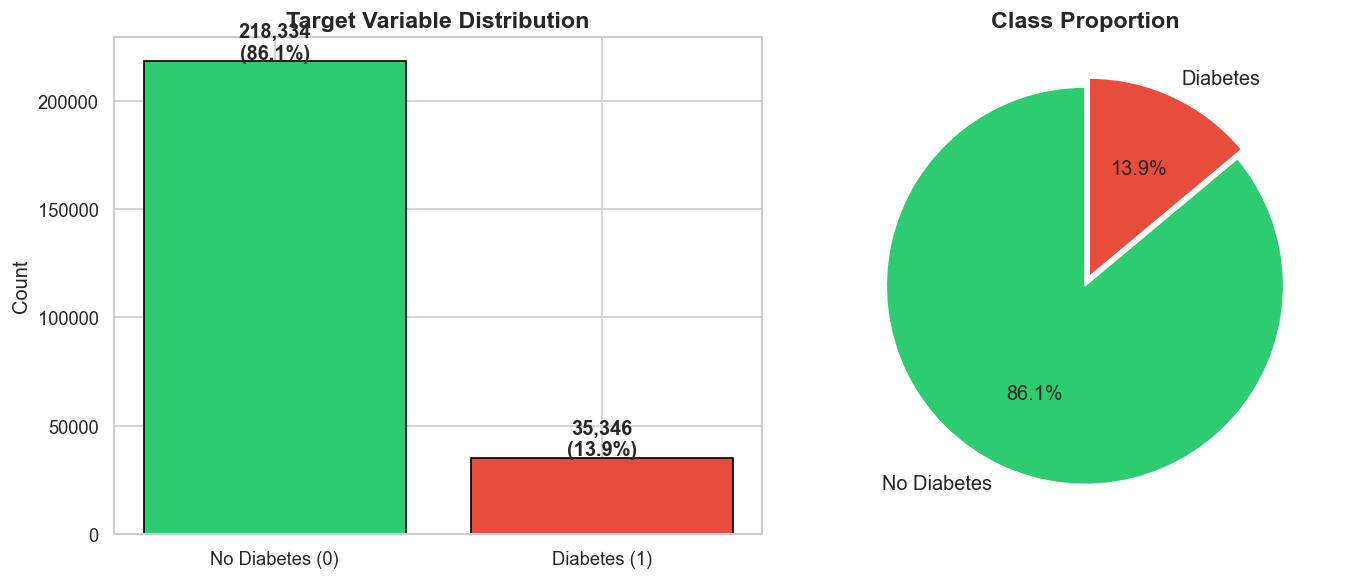


⚠️  Class imbalance ratio: 6.18:1 (No Diabetes : Diabetes)
→ We will need to handle this with SMOTE or class weights.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
counts = df['Diabetes_binary'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"\n⚠️  Class imbalance ratio: {imbalance_ratio:.2f}:1 (No Diabetes : Diabetes)")
print("→ We will need to handle this with SMOTE or class weights.")

**Analysis — Class Imbalance:**

The target variable exhibits severe class imbalance: 218,334 respondents (86.1%) have no diabetes versus only 35,346 (13.9%) with diabetes/prediabetes, yielding an imbalance ratio of approximately 6.2:1. This is a critical finding with direct modelling implications — a naïve classifier that predicts "no diabetes" for every observation would achieve 86.1% accuracy, rendering accuracy alone a misleading performance metric. This motivates our choice of ROC-AUC and F1-score as primary evaluation metrics, and necessitates resampling (SMOTE) or class weighting during training to prevent the minority class from being overwhelmed. The 13.9% prevalence is broadly consistent with CDC estimates of US diabetes prevalence (~14%), suggesting the survey sampling is representative of the population-level burden.

### 2.2 Feature Distributions by Target

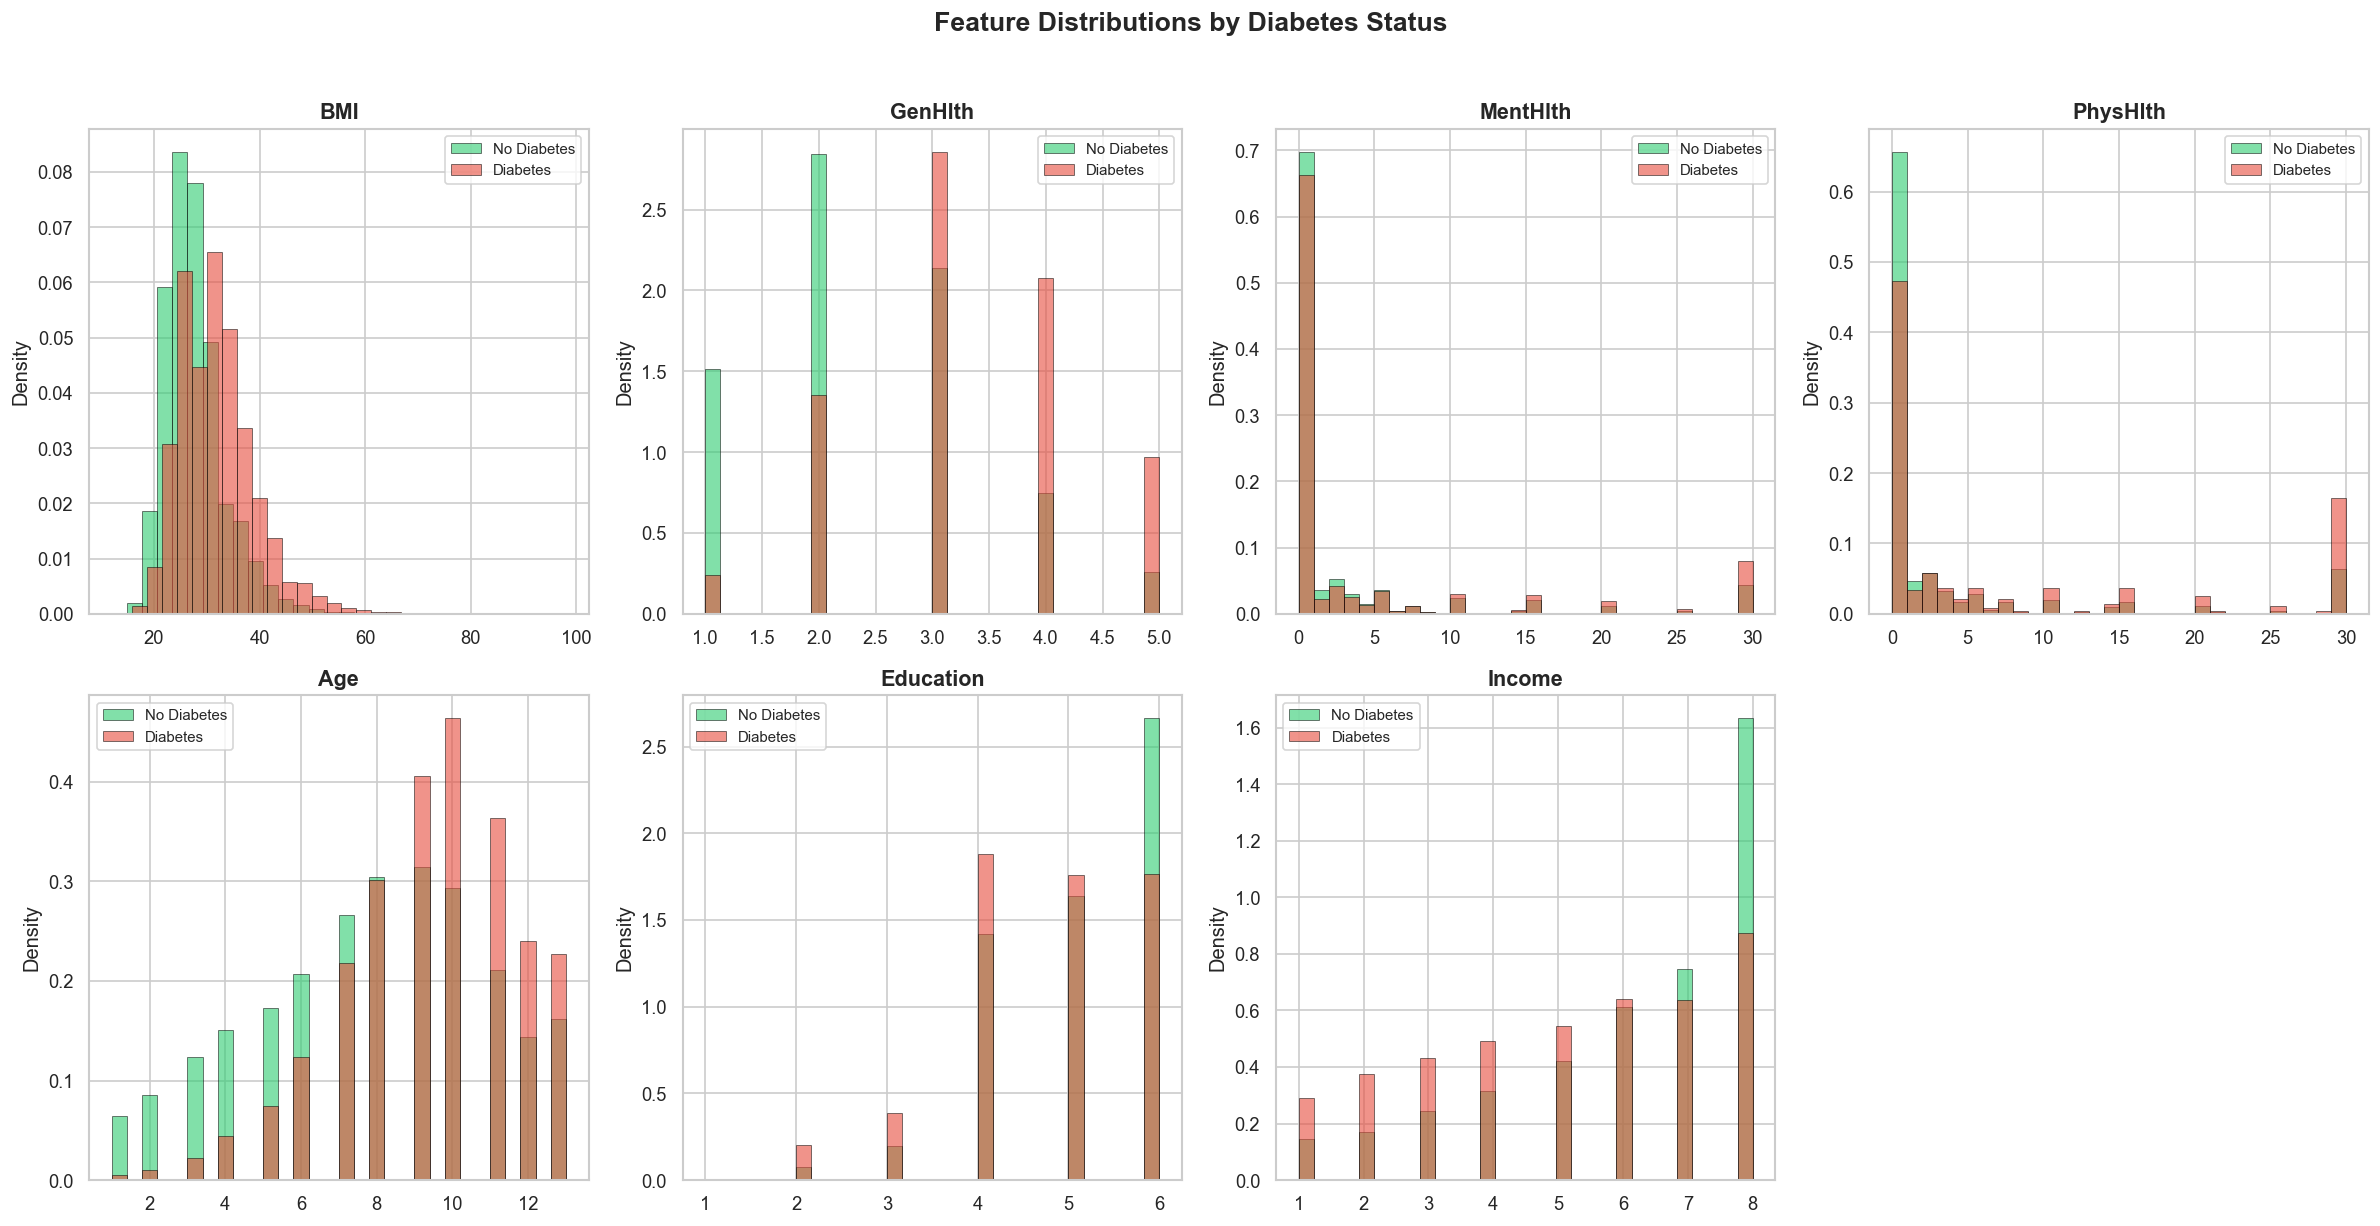

In [9]:
# Continuous / ordinal features — distributions by diabetes status
continuous_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    for label, color, name in [(0, '#2ecc71', 'No Diabetes'), (1, '#e74c3c', 'Diabetes')]:
        subset = df[df['Diabetes_binary'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True, edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

# Remove unused subplot
axes[-1].axis('off')

plt.suptitle('Feature Distributions by Diabetes Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis — Feature Distributions by Diabetes Status:**

Several features show clear distributional shifts between the two classes, indicating strong predictive potential:

- **BMI:** The diabetes group's distribution is visibly right-shifted, peaking around 30–35 compared to 25–28 for the non-diabetic group. This aligns with the well-established clinical link between obesity (BMI ≥ 30) and type 2 diabetes. The long right tail extending past 60 signals extreme outliers that will need capping.
- **GenHlth** (1=excellent to 5=poor): This is the most discriminative feature. Non-diabetic respondents are heavily concentrated at values 1–3 (good to excellent health), while the diabetes group shifts dramatically toward 4–5 (fair to poor). This is expected — people with a chronic condition self-report worse general health — but raises a subtle concern: GenHlth could partially reflect *awareness* of diabetes status rather than being a truly independent predictor.
- **Age:** The diabetes group skews heavily toward older age categories (9–12, roughly age 55–75+), while the non-diabetic group is more uniformly distributed across categories 4–12. This confirms age as a major risk factor and suggests potential interaction effects with other features.
- **MentHlth & PhysHlth:** Both are heavily zero-inflated (most respondents report 0 days of poor health), but the diabetes group shows a fatter tail — more respondents reporting 15–30 days of poor physical and mental health. PhysHlth shows stronger separation than MentHlth.
- **Income:** The non-diabetic group is concentrated at income levels 7–8 (highest brackets), while the diabetes group is more evenly spread across all levels, with greater representation at lower incomes (1–4). This reflects the socioeconomic gradient in diabetes prevalence.
- **Education:** Both groups peak at levels 5–6 (college education), but the diabetes group has slightly higher representation at lower education levels. The separation is weaker than for income.

### 2.3 Binary Feature Prevalence by Target

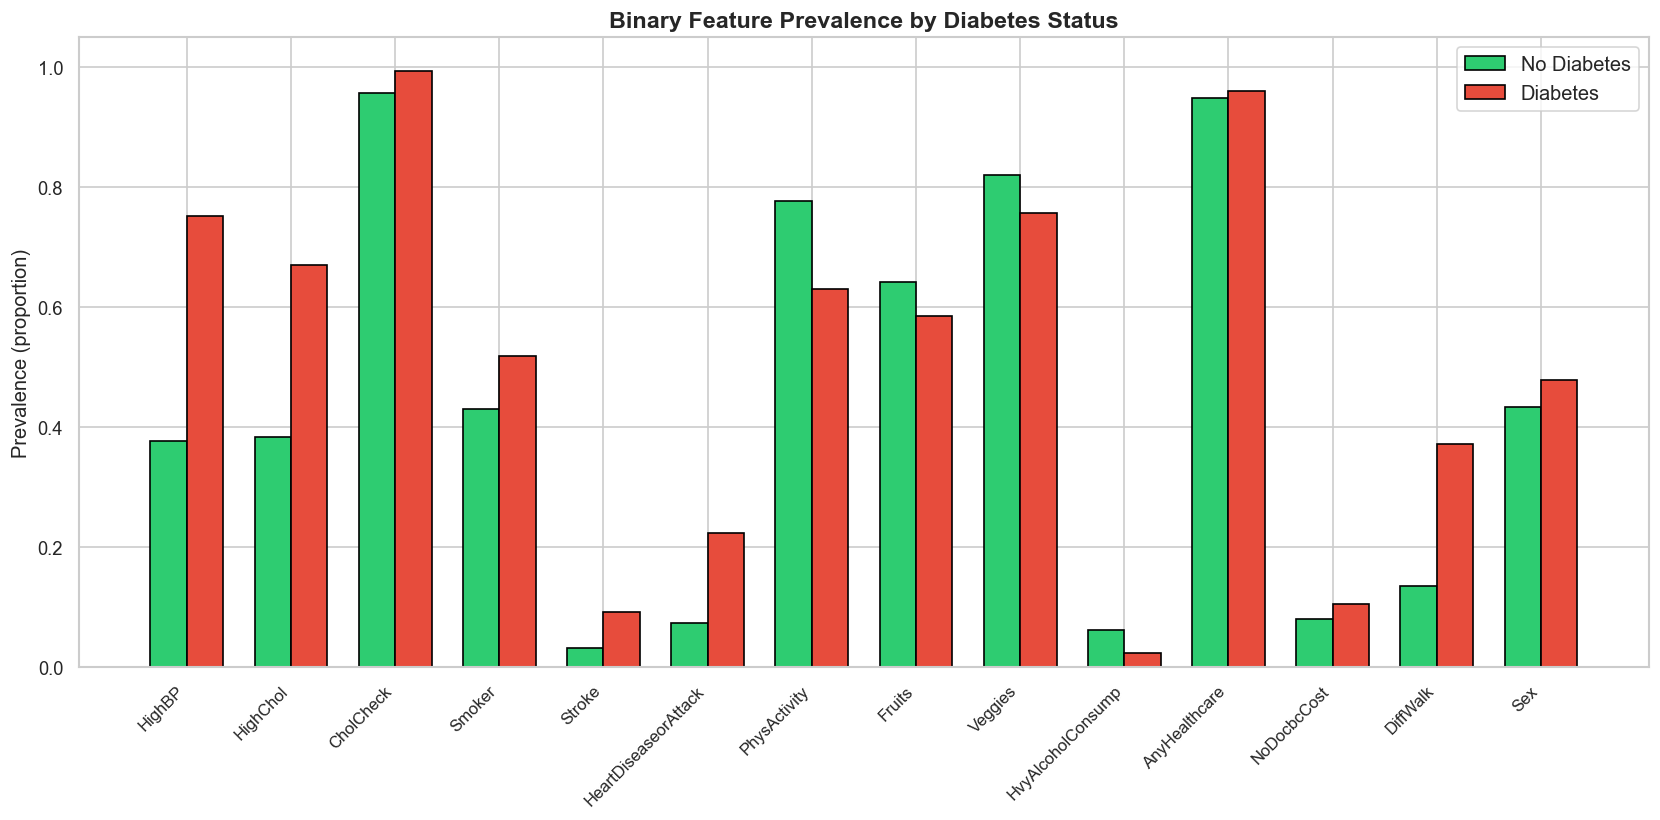


🔍 Key observations:
• HighBP and HighChol show the strongest separation between classes
• DiffWalk and HeartDiseaseorAttack are much more prevalent in diabetic group
• PhysActivity is lower in the diabetic group — protective factor


In [10]:
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                   'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                   'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

# Calculate prevalence of each binary feature by diabetes status
prevalence = df.groupby('Diabetes_binary')[binary_features].mean()

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(binary_features))
width = 0.35

bars1 = ax.bar(x - width/2, prevalence.loc[0], width, label='No Diabetes', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, prevalence.loc[1], width, label='Diabetes', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Prevalence (proportion)', fontsize=12)
ax.set_title('Binary Feature Prevalence by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(binary_features, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_03_binary_feature_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Key observations:")
print("• HighBP and HighChol show the strongest separation between classes")
print("• DiffWalk and HeartDiseaseorAttack are much more prevalent in diabetic group")
print("• PhysActivity is lower in the diabetic group — protective factor")

**Analysis — Binary Feature Prevalence:**

This plot reveals which binary health indicators differ most between diabetic and non-diabetic groups:

- **HighBP** shows the single largest absolute gap: ~75% prevalence in the diabetes group versus ~38% in the non-diabetic group — nearly double. High blood pressure is a well-known comorbidity of type 2 diabetes, sharing underlying mechanisms such as insulin resistance and vascular damage.
- **HighChol** follows a similar pattern (~67% vs ~39%), reinforcing that metabolic syndrome features cluster together and will likely be strong predictors.
- **DiffWalk** (difficulty walking) shows a striking threefold increase: ~37% in diabetic respondents versus ~13% in non-diabetic. This captures the mobility complications associated with diabetes (neuropathy, obesity-related joint issues).
- **HeartDiseaseorAttack** jumps from ~8% to ~23% — a near-threefold relative increase — consistent with diabetes being a major cardiovascular risk factor.
- **PhysActivity** is notably *lower* in the diabetes group (~63% vs ~78%), suggesting it acts as a protective factor. This is one of the few features where the diabetic group has a *lower* prevalence.
- **CholCheck** and **AnyHealthcare** are near-ceiling for both groups (>95%), meaning they carry almost no discriminative power — nearly everyone in both classes has healthcare and recent cholesterol checks. These features may add noise rather than signal.
- **HvyAlcoholConsump** is slightly *lower* in the diabetes group (~3% vs ~6%), which is counterintuitive but may reflect survivor bias or behaviour modification after diagnosis.
- **Sex** shows minimal difference between groups, suggesting diabetes risk is relatively gender-balanced in this dataset.


### 2.4 Correlation Analysis

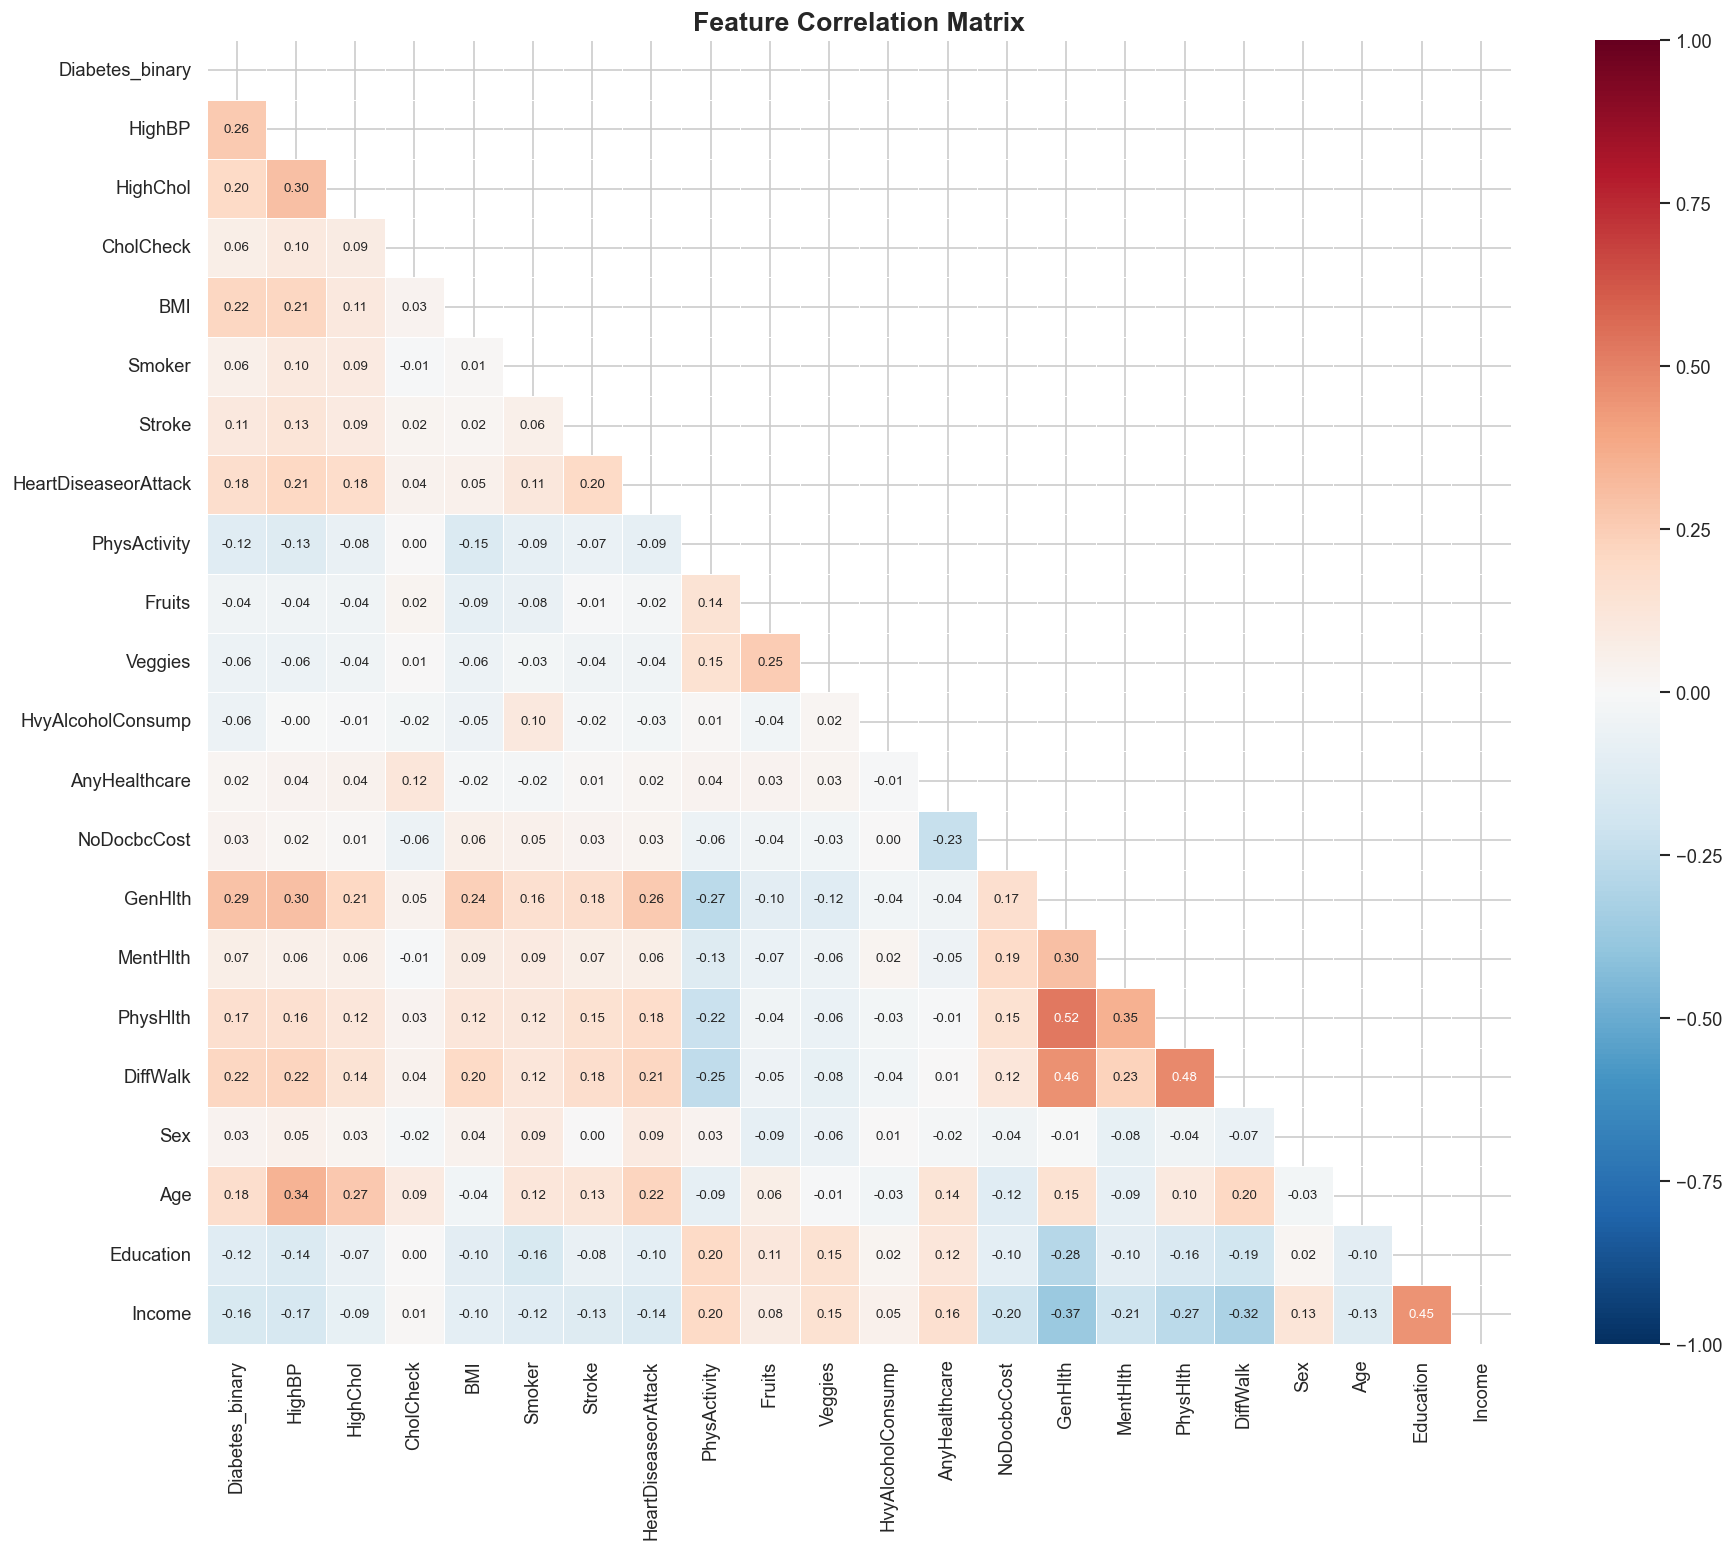


📊 Correlations with Diabetes_binary (sorted):
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919


In [11]:
# Full correlation matrix
fig, ax = plt.subplots(figsize=(16, 13))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlations with target
target_corr = corr['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
print("\n📊 Correlations with Diabetes_binary (sorted):")
print(target_corr.to_string())

**Analysis — Correlation Matrix:**

The heatmap reveals the internal correlation structure of the feature space:

- **No features are dangerously collinear** (no pairwise correlations exceed 0.52), which means multicollinearity is unlikely to destabilise our models. This is good news for both interpretability and model stability.
- The strongest inter-feature correlations are: PhysHlth–MentHlth (0.52), PhysHlth–DiffWalk (0.48), Education–Income (0.45), and HighBP–Age (0.34). These make clinical sense — poor physical health coincides with poor mental health and mobility problems, while education and income are socioeconomically linked.
- **GenHlth acts as a hub variable**, showing moderate positive correlations with multiple risk factors (HighBP: 0.30, DiffWalk: 0.46, PhysHlth: 0.35) and negative correlations with protective factors (PhysActivity: −0.27, Income: −0.37). This makes it a powerful predictor but also one that partially encodes information from other features — worth monitoring for redundancy.
- The cluster of correlated health burden features (GenHlth, PhysHlth, MentHlth, DiffWalk) suggests an underlying latent factor representing "overall health deterioration" that drives much of the diabetes signal.
- **Protective factors** (PhysActivity, Income, Education, Fruits, Veggies) are negatively correlated with diabetes but also positively correlated *with each other*, reflecting a socioeconomic-health lifestyle cluster.

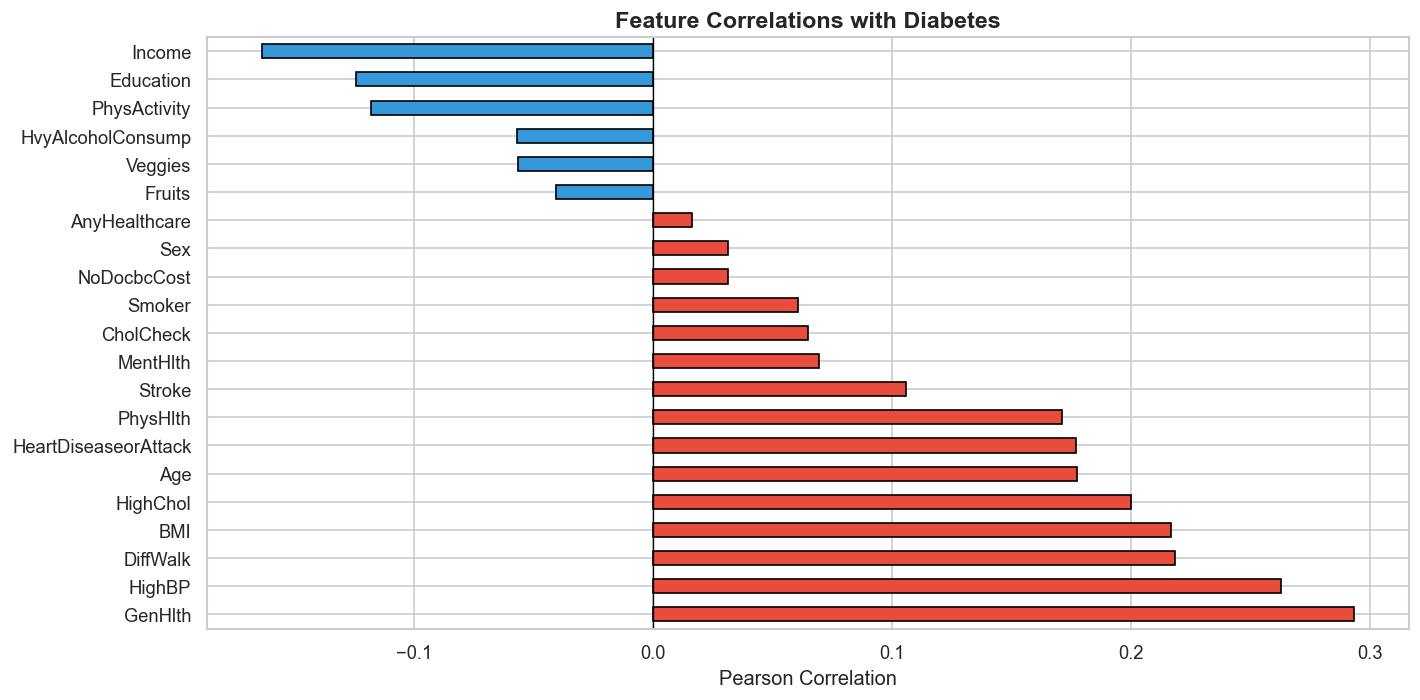

In [12]:
# Bar chart of correlations with target
fig, ax = plt.subplots(figsize=(12, 6))
colors_corr = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr]
target_corr.plot(kind='barh', color=colors_corr, edgecolor='black', ax=ax)
ax.set_title('Feature Correlations with Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_05_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis — Feature Correlations with Target:**

Ranked by Pearson correlation with `Diabetes_binary`, the top positive predictors are: GenHlth (0.29), HighBP (0.26), BMI (0.22), DiffWalk (0.22), HighChol (0.20), HeartDiseaseorAttack (0.18), Age (0.18), and PhysHlth (0.17). The top negative (protective) correlations are: Income (−0.16), Education (−0.12), and PhysActivity (−0.12).

While no individual correlation exceeds 0.30 — which is relatively modest — this is expected for survey-based health data where diabetes is influenced by many interacting factors rather than any single dominant predictor. This reinforces the rationale for using ensemble and non-linear models (Random Forest, XGBoost, neural networks) that can capture interaction effects and non-linear relationships that linear correlations miss.

Notably, **HvyAlcoholConsump has a weakly negative correlation (−0.06)** with diabetes, which seems paradoxical. This likely reflects confounding: heavy drinkers in the survey may be younger and thinner on average, or individuals diagnosed with diabetes may have reduced their alcohol intake. This is a reminder that Pearson correlation captures linear association only, not causation.

Features with near-zero correlations (AnyHealthcare: 0.02, Sex: 0.03, NoDocbcCost: 0.03) are unlikely to contribute much independently but may still participate in useful feature interactions within tree-based models.

### 2.5 Check for Data Leakage Risks

In [13]:
print("=" * 60)
print("LEAKAGE RISK ASSESSMENT")
print("=" * 60)
print()
print("Checking for suspiciously high correlations with target...")
high_corr = target_corr[abs(target_corr) > 0.5]
if len(high_corr) > 0:
    print(f"⚠️  Features with |correlation| > 0.5: {list(high_corr.index)}")
else:
    print("✅ No features with |correlation| > 0.5 — low leakage risk")

print(f"\nHighest correlation: {target_corr.index[0]} = {target_corr.iloc[0]:.3f}")
print("→ GenHlth is self-reported general health; while correlated, it's")
print("  a legitimate predictor (not derived from diabetes diagnosis).")

print("\n🔍 Leakage verdict: No obvious leakage detected.")
print("   All features are pre-existing health indicators, not consequences of diagnosis.")
print("   However, GenHlth could be influenced by diabetes awareness — noted as limitation.")

LEAKAGE RISK ASSESSMENT

Checking for suspiciously high correlations with target...
✅ No features with |correlation| > 0.5 — low leakage risk

Highest correlation: GenHlth = 0.294
→ GenHlth is self-reported general health; while correlated, it's
  a legitimate predictor (not derived from diabetes diagnosis).

🔍 Leakage verdict: No obvious leakage detected.
   All features are pre-existing health indicators, not consequences of diagnosis.
   However, GenHlth could be influenced by diabetes awareness — noted as limitation.


### 2.6 Duplicate Rows & Outlier Analysis

Duplicate rows: 24,206 (9.5% of data)
→ Survey data can have legitimate duplicates (different people, same answers).
→ We will keep duplicates to preserve the true data distribution.

OUTLIER ANALYSIS (BMI)


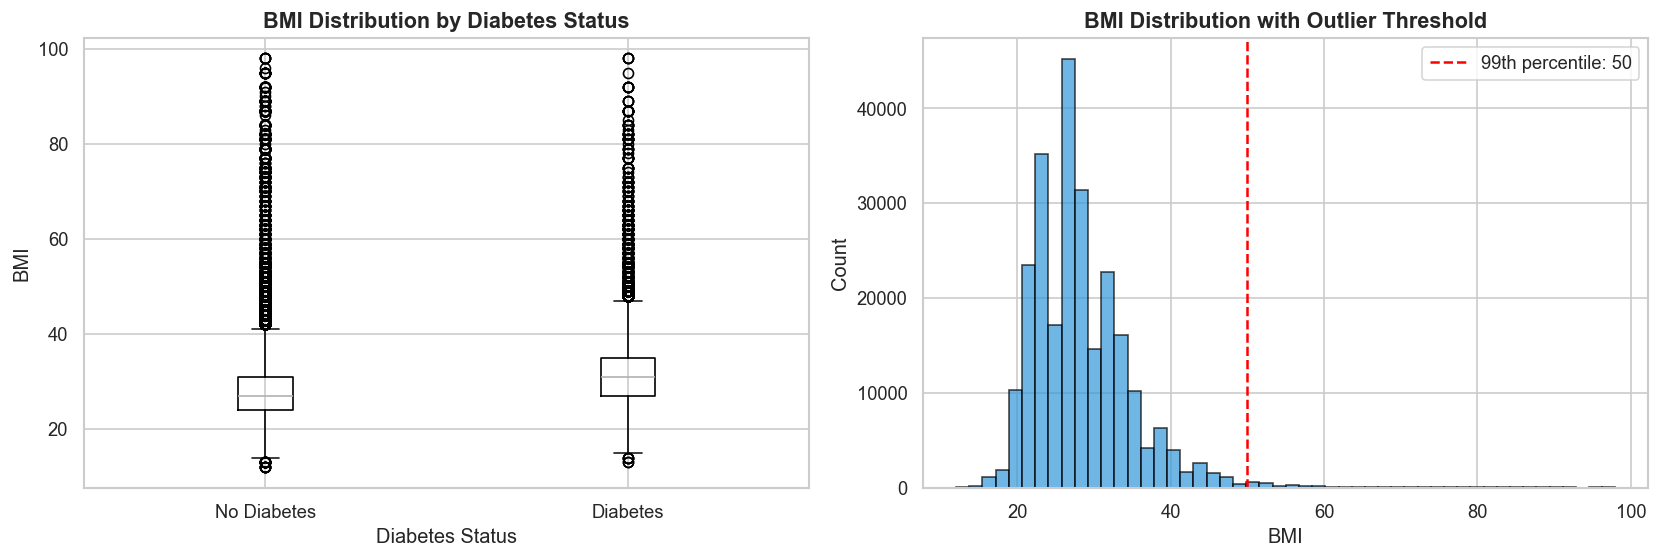

BMI range: 12 – 98
BMI > 60: 805 rows (0.32%)
→ Extreme BMI values exist but are plausible; we will cap at 99th percentile.


In [14]:
# Check duplicates
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates/len(df)*100:.1f}% of data)")
print("→ Survey data can have legitimate duplicates (different people, same answers).")
print("→ We will keep duplicates to preserve the true data distribution.")

print(f"\n{'='*60}")
print("OUTLIER ANALYSIS (BMI)")
print(f"{'='*60}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI boxplot by class
df.boxplot(column='BMI', by='Diabetes_binary', ax=axes[0])
axes[0].set_title('BMI Distribution by Diabetes Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('BMI')
plt.sca(axes[0])
plt.xticks([1, 2], ['No Diabetes', 'Diabetes'])

# BMI distribution
axes[1].hist(df['BMI'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].axvline(df['BMI'].quantile(0.99), color='red', linestyle='--', label=f'99th percentile: {df["BMI"].quantile(0.99):.0f}')
axes[1].set_title('BMI Distribution with Outlier Threshold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('', fontsize=1)  # Remove automatic suptitle from boxplot
plt.tight_layout()
plt.savefig('fig_06_bmi_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"BMI range: {df['BMI'].min()} – {df['BMI'].max()}")
print(f"BMI > 60: {(df['BMI'] > 60).sum()} rows ({(df['BMI'] > 60).sum()/len(df)*100:.2f}%)")
print("→ Extreme BMI values exist but are plausible; we will cap at 99th percentile.")

**Analysis — BMI Outliers:**

The boxplot confirms that the diabetes group has a higher median BMI (~31, in the "obese" range) compared to the non-diabetic group (~27, "overweight" range), with the interquartile range shifted upward. Both groups exhibit extreme outliers extending well beyond BMI 60, with some values reaching 95–98. While BMI values above 60 are medically plausible (severe morbid obesity), they are extremely rare and could disproportionately influence model training.

The right-panel histogram shows a right-skewed distribution with a long tail: the vast majority of respondents fall between BMI 18–45, and the 99th percentile sits at BMI 50. We apply Winsorisation (capping) at this 99th percentile to reduce the influence of extreme outliers without removing valid observations. Importantly, we compute this threshold from the *training set only* and apply it to all splits, preventing information leakage from the validation or test sets into our preprocessing.

The decision to cap rather than remove outliers is deliberate: removing rows with high BMI would systematically exclude the most severe obesity cases, which are precisely the highest-risk individuals for diabetes — this would bias the model's ability to identify high-risk patients.

<a id='step3'></a>
---
# Step 3: Prepare the Data

We build a reproducible preprocessing pipeline with:
- Train / Validation / Test split (before any transformations to prevent leakage)
- BMI outlier capping
- Feature scaling
- SMOTE for class imbalance (applied only to training data)

In [15]:
# ── Separate features and target ──
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

Features shape: (253680, 21)
Target shape: (253680,)
Target distribution:
Diabetes_binary
0    0.861
1    0.139
Name: proportion, dtype: float64


In [16]:
# ── IMPORTANT: Split BEFORE any preprocessing to prevent data leakage ──
# 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"\nTarget distribution preserved across splits:")
for name, data in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: {data.mean()*100:.1f}% positive")

Training set:   152,208 rows (60%)
Validation set: 50,736 rows (20%)
Test set:       50,736 rows (20%)

Target distribution preserved across splits:
  Train: 13.9% positive
  Val: 13.9% positive
  Test: 13.9% positive


In [17]:
# ── Data Validation Checks ──
print("=" * 60)
print("DATA VALIDATION CHECKS")
print("=" * 60)

# Check 1: No missing values
assert X_train.isnull().sum().sum() == 0, "Missing values found in training data!"
print("✅ Check 1: No missing values")

# Check 2: No overlap between splits
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)
assert len(train_idx & val_idx) == 0, "Train-Val overlap detected!"
assert len(train_idx & test_idx) == 0, "Train-Test overlap detected!"
assert len(val_idx & test_idx) == 0, "Val-Test overlap detected!"
print("✅ Check 2: No data leakage between splits")

# Check 3: Stratification preserved
for name, data in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    ratio = data.mean()
    assert abs(ratio - y.mean()) < 0.01, f"Stratification failed for {name}!"
print("✅ Check 3: Stratified split successful (class ratios preserved)")

# Check 4: Feature ranges are reasonable
assert X_train['BMI'].min() >= 0, "Negative BMI found!"
assert X_train['Age'].max() <= 13, "Invalid Age category!"
print("✅ Check 4: Feature value ranges are valid")

print("\n🎉 All data validation checks passed!")

DATA VALIDATION CHECKS
✅ Check 1: No missing values
✅ Check 2: No data leakage between splits
✅ Check 3: Stratified split successful (class ratios preserved)
✅ Check 4: Feature value ranges are valid

🎉 All data validation checks passed!


In [18]:
# ── BMI Outlier Capping (using TRAINING data statistics only) ──
bmi_cap = X_train['BMI'].quantile(0.99)
print(f"BMI cap (99th percentile from training data): {bmi_cap}")

X_train['BMI'] = X_train['BMI'].clip(upper=bmi_cap)
X_val['BMI'] = X_val['BMI'].clip(upper=bmi_cap)
X_test['BMI'] = X_test['BMI'].clip(upper=bmi_cap)

print(f"After capping — BMI max in train: {X_train['BMI'].max()}, val: {X_val['BMI'].max()}, test: {X_test['BMI'].max()}")

BMI cap (99th percentile from training data): 49.0
After capping — BMI max in train: 49, val: 49, test: 49


In [19]:
# ── Feature Scaling (fit on training data only) ──
scaler = StandardScaler()
feature_names = X_train.columns.tolist()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=feature_names, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print("✅ Scaling complete (fit on training data, applied to all splits)")
print(f"\nTraining set means (should be ≈0):\n{X_train_scaled.mean().round(4).to_string()}")

✅ Scaling complete (fit on training data, applied to all splits)

Training set means (should be ≈0):
HighBP                 -0.0
HighChol                0.0
CholCheck              -0.0
BMI                     0.0
Smoker                  0.0
Stroke                  0.0
HeartDiseaseorAttack   -0.0
PhysActivity           -0.0
Fruits                 -0.0
Veggies                -0.0
HvyAlcoholConsump       0.0
AnyHealthcare           0.0
NoDocbcCost            -0.0
GenHlth                -0.0
MentHlth               -0.0
PhysHlth                0.0
DiffWalk               -0.0
Sex                    -0.0
Age                    -0.0
Education              -0.0
Income                 -0.0


In [20]:
# ── SMOTE for Class Imbalance (applied ONLY to training data) ──
print("Before SMOTE:")
print(f"  Training set: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training set: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"  Training set size: {len(X_train_smote):,} (was {len(X_train_scaled):,})")
print("\n⚠️  SMOTE applied ONLY to training data — validation and test sets remain untouched.")

Before SMOTE:
  Training set: {0: 131000, 1: 21208}

After SMOTE:
  Training set: {0: 131000, 1: 131000}
  Training set size: 262,000 (was 152,208)

⚠️  SMOTE applied ONLY to training data — validation and test sets remain untouched.


<a id='step4'></a>
---
# Step 4: Explore Models & Shortlist

We compare:
1. **Logistic Regression** (baseline, interpretable)
2. **Random Forest** (ensemble, non-linear)
3. **XGBoost** (gradient boosting, state-of-the-art for tabular data)
4. **LightGBM** (efficient gradient boosting)
5. **Neural Network** (deep learning — modern approach, required by brief)

In [23]:
# ── Helper function for model evaluation ──
def evaluate_model(model, X_tr, y_tr, X_v, y_v, model_name, is_keras=False):
    """
    Train a model and evaluate it on the validation set.
    Returns a dictionary of metrics.
    """
    if is_keras:
        y_pred_proba = model.predict(X_v, verbose=0).flatten()
        y_pred = (y_pred_proba >= 0.5).astype(int)
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_v)
        y_pred_proba = model.predict_proba(X_v)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_v, y_pred),
        'F1': f1_score(y_v, y_pred),
        'ROC-AUC': roc_auc_score(y_v, y_pred_proba),
        'Avg Precision': average_precision_score(y_v, y_pred_proba),
    }
    
    print(f"\n{'─'*50}")
    print(f"📊 {model_name}")
    print(f"{'─'*50}")
    print(f"  Accuracy:        {metrics['Accuracy']:.4f}")
    print(f"  F1-Score:        {metrics['F1']:.4f}")
    print(f"  ROC-AUC:         {metrics['ROC-AUC']:.4f}")
    print(f"  Avg Precision:   {metrics['Avg Precision']:.4f}")
    
    return metrics, y_pred, y_pred_proba

### 4.1 Baseline: Logistic Regression

In [24]:
# ── Model 1: Logistic Regression (baseline) ──
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_metrics, lr_pred, lr_proba = evaluate_model(
    lr_model, X_train_smote, y_train_smote, X_val_scaled, y_val, 'Logistic Regression'
)


──────────────────────────────────────────────────
📊 Logistic Regression
──────────────────────────────────────────────────
  Accuracy:        0.7342
  F1-Score:        0.4425
  ROC-AUC:         0.8218
  Avg Precision:   0.4142


### 4.2 Random Forest

In [25]:
# ── Model 2: Random Forest ──
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train_smote, y_train_smote, X_val_scaled, y_val, 'Random Forest'
)


──────────────────────────────────────────────────
📊 Random Forest
──────────────────────────────────────────────────
  Accuracy:        0.8179
  F1-Score:        0.4599
  ROC-AUC:         0.8208
  Avg Precision:   0.4125


### 4.3 XGBoost

In [26]:
# ── Model 3: XGBoost ──
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric='logloss',
    use_label_encoder=False, n_jobs=-1
)
xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_train_smote, y_train_smote, X_val_scaled, y_val, 'XGBoost'
)


──────────────────────────────────────────────────
📊 XGBoost
──────────────────────────────────────────────────
  Accuracy:        0.8664
  F1-Score:        0.2882
  ROC-AUC:         0.8259
  Avg Precision:   0.4298


### 4.4 LightGBM

In [27]:
# ── Model 4: LightGBM ──
lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbose=-1
)
lgbm_metrics, lgbm_pred, lgbm_proba = evaluate_model(
    lgbm_model, X_train_smote, y_train_smote, X_val_scaled, y_val, 'LightGBM'
)


──────────────────────────────────────────────────
📊 LightGBM
──────────────────────────────────────────────────
  Accuracy:        0.8659
  F1-Score:        0.2849
  ROC-AUC:         0.8258
  Avg Precision:   0.4288


### 4.5 Neural Network (Modern Approach)

In [28]:
# ── Model 5: Neural Network (Keras) ──
def build_nn(input_dim):
    """
    Build a feedforward neural network for binary classification.
    Architecture: Input → 128 → Dropout → 64 → Dropout → 32 → Dropout → 1
    Uses batch normalisation and dropout for regularisation.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

nn_model = build_nn(X_train_smote.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,633 (53.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
# ── Train the Neural Network with Early Stopping ──
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1
)

history = nn_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8131 - loss: 0.5268 - val_AUC: 0.8246 - val_loss: 0.5292 - learning_rate: 0.0010
Epoch 2/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8353 - loss: 0.4945 - val_AUC: 0.8248 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 3/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8400 - loss: 0.4886 - val_AUC: 0.8245 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 4/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8425 - loss: 0.4851 - val_AUC: 0.8234 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 5/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8444 - loss: 0.4827 - val_AUC: 0.8232 - val_loss: 0.5145 - learning_rate: 0.0010
Epoch 6/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8457 - loss: 0.4812 - val_AUC: 0.8222 - val_loss: 0.5103 - learning_rate: 0.0010
Epoch 7/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8470 - loss: 0.4797 - val_AUC: 0.8220 - val_loss: 0.5161 - learning_rate: 0.0010

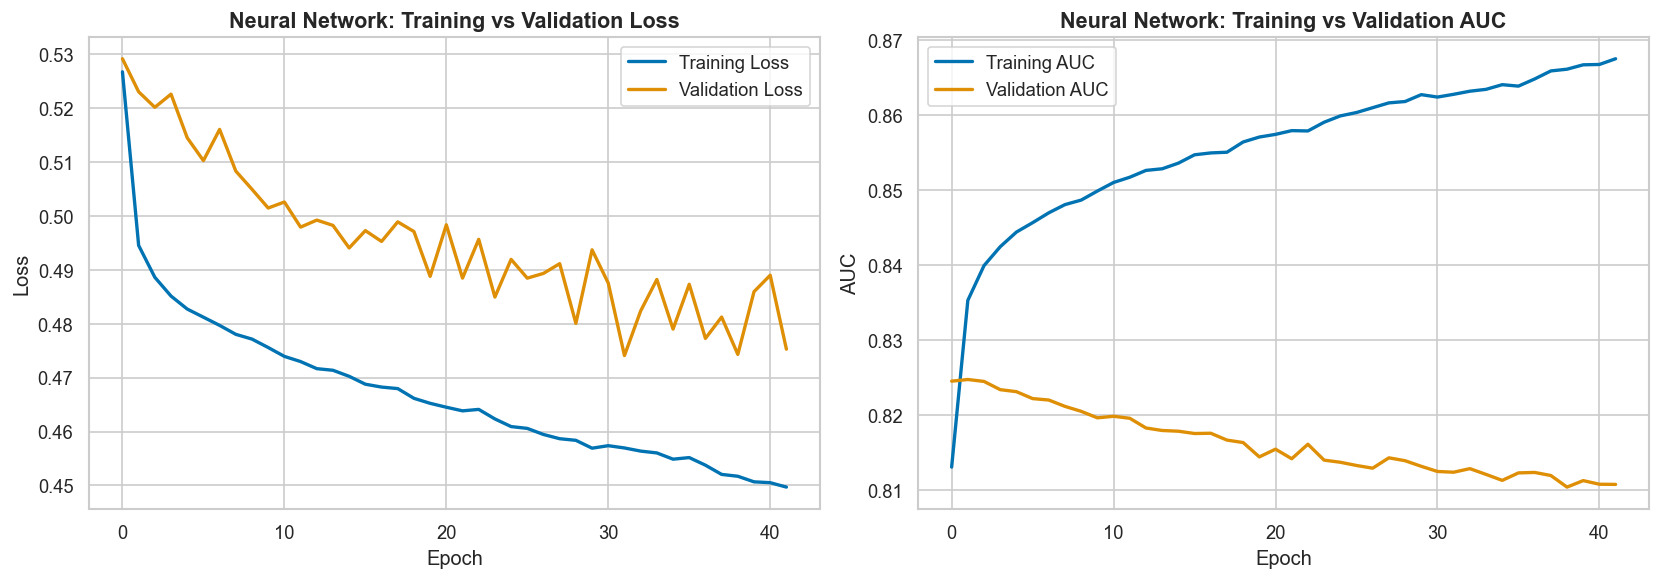

In [38]:
# ── Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Neural Network: Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)

# AUC
axes[1].plot(history.history['AUC'], label='Training AUC', linewidth=2)
axes[1].plot(history.history['val_AUC'], label='Validation AUC', linewidth=2)
axes[1].set_title('Neural Network: Training vs Validation AUC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_07_nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ── Evaluate Neural Network ──
nn_metrics, nn_pred, nn_proba = evaluate_model(
    nn_model, X_train_smote, y_train_smote, X_val_scaled, y_val, 'Neural Network', is_keras=True
)


──────────────────────────────────────────────────
📊 Neural Network
──────────────────────────────────────────────────
  Accuracy:        0.7569
  F1-Score:        0.4432
  ROC-AUC:         0.8125
  Avg Precision:   0.4106


### 4.6 Model Comparison Summary

In [40]:
# ── Compare all models ──
all_metrics = [lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics, nn_metrics]
comparison_df = pd.DataFrame(all_metrics).set_index('Model')

# Style the dataframe
print("\n" + "=" * 60)
print("MODEL COMPARISON (Validation Set)")
print("=" * 60)
print(comparison_df.round(4).to_string())

best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best model by ROC-AUC: {best_model_name} ({comparison_df.loc[best_model_name, 'ROC-AUC']:.4f})")


MODEL COMPARISON (Validation Set)
                     Accuracy      F1  ROC-AUC  Avg Precision
Model                                                        
Logistic Regression    0.7342  0.4425   0.8218         0.4142
Random Forest          0.8179  0.4599   0.8208         0.4125
XGBoost                0.8664  0.2882   0.8259         0.4298
LightGBM               0.8659  0.2849   0.8258         0.4288
Neural Network         0.7569  0.4432   0.8125         0.4106

🏆 Best model by ROC-AUC: XGBoost (0.8259)


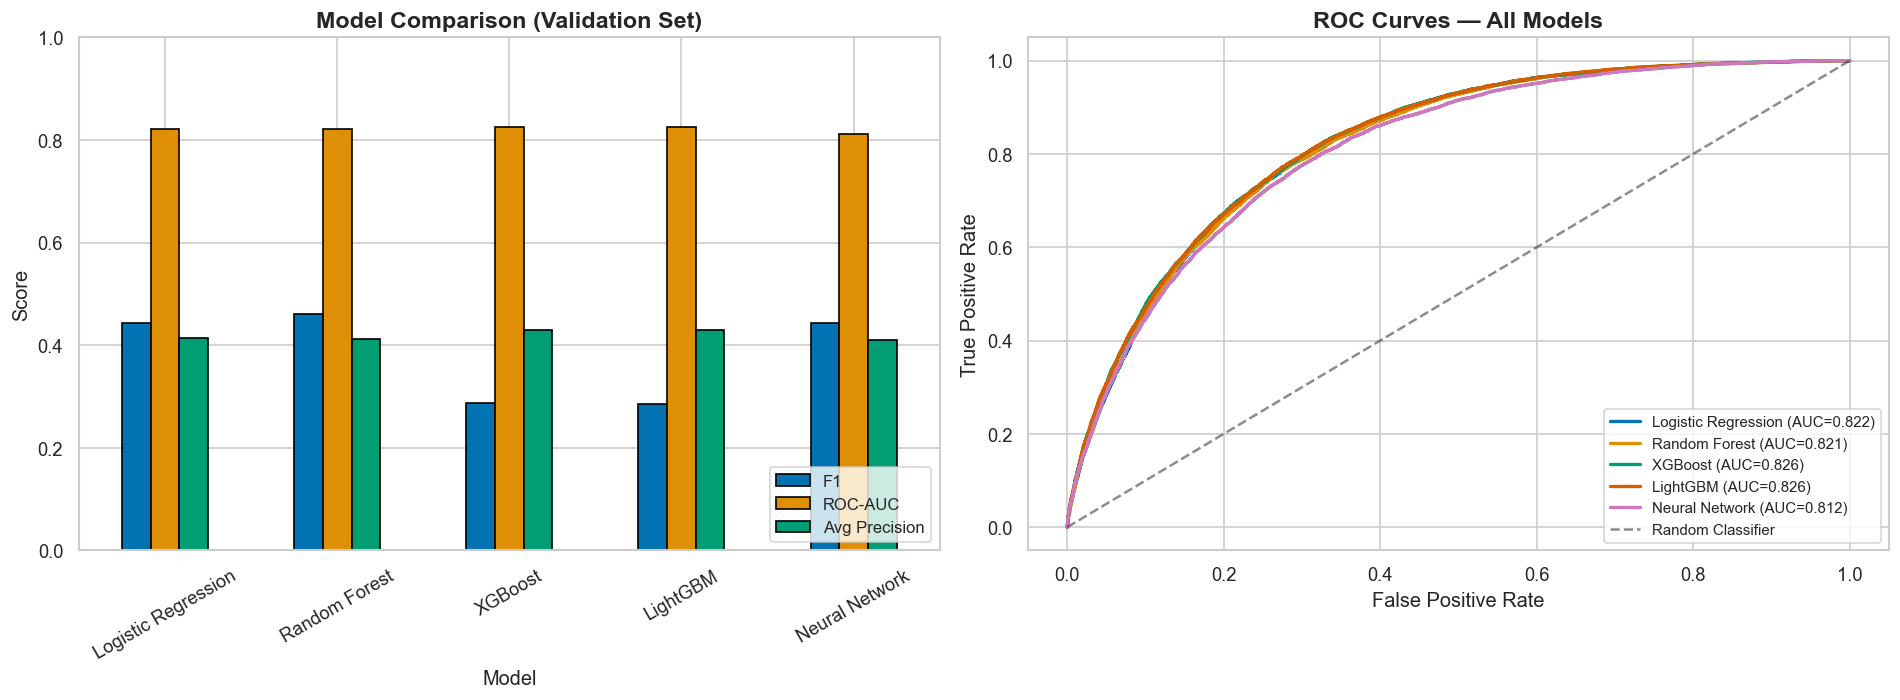

In [41]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of metrics
comparison_df[['F1', 'ROC-AUC', 'Avg Precision']].plot(
    kind='bar', ax=axes[0], edgecolor='black', rot=30
)
axes[0].set_title('Model Comparison (Validation Set)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=10)

# ROC curves
all_models_data = [
    ('Logistic Regression', lr_proba),
    ('Random Forest', rf_proba),
    ('XGBoost', xgb_proba),
    ('LightGBM', lgbm_proba),
    ('Neural Network', nn_proba),
]

for name, proba in all_models_data:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='step5'></a>
---
# Step 5: Fine-Tune & Evaluate

We fine-tune the two best-performing models using Randomized Search CV,  
then perform deep evaluation including confusion matrices, calibration, and error analysis.

### 5.1 Hyperparameter Tuning — LightGBM (with Cross-Validation)

In [42]:
# ── Hyperparameter tuning for LightGBM ──
lgbm_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [20, 50, 100],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("🔍 Running Randomized Search CV for LightGBM (30 iterations, 5-fold CV)...")
lgbm_search.fit(X_train_smote, y_train_smote)

print(f"\n✅ Best parameters: {lgbm_search.best_params_}")
print(f"Best CV ROC-AUC: {lgbm_search.best_score_:.4f}")

🔍 Running Randomized Search CV for LightGBM (30 iterations, 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9722


In [44]:
# ── Evaluate tuned LightGBM on validation set ──
lgbm_tuned = lgbm_search.best_estimator_
lgbm_tuned_proba = lgbm_tuned.predict_proba(X_val_scaled)[:, 1]
lgbm_tuned_pred = lgbm_tuned.predict(X_val_scaled)

print(f"Tuned LightGBM Validation Results:")
print(f"  ROC-AUC:       {roc_auc_score(y_val, lgbm_tuned_proba):.4f}")
print(f"  F1-Score:      {f1_score(y_val, lgbm_tuned_pred):.4f}")
print(f"  Accuracy:      {accuracy_score(y_val, lgbm_tuned_pred):.4f}")

Tuned LightGBM Validation Results:
  ROC-AUC:       0.8267
  F1-Score:      0.2880
  Accuracy:      0.8660


### 5.2 Hyperparameter Tuning — XGBoost

In [45]:
# ── Hyperparameter tuning for XGBoost ──
xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("🔍 Running Randomized Search CV for XGBoost (30 iterations, 5-fold CV)...")
xgb_search.fit(X_train_smote, y_train_smote)

print(f"\n✅ Best parameters: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

🔍 Running Randomized Search CV for XGBoost (30 iterations, 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9714


In [46]:
# ── Evaluate tuned XGBoost ──
xgb_tuned = xgb_search.best_estimator_
xgb_tuned_proba = xgb_tuned.predict_proba(X_val_scaled)[:, 1]
xgb_tuned_pred = xgb_tuned.predict(X_val_scaled)

print(f"Tuned XGBoost Validation Results:")
print(f"  ROC-AUC:       {roc_auc_score(y_val, xgb_tuned_proba):.4f}")
print(f"  F1-Score:      {f1_score(y_val, xgb_tuned_pred):.4f}")
print(f"  Accuracy:      {accuracy_score(y_val, xgb_tuned_pred):.4f}")

Tuned XGBoost Validation Results:
  ROC-AUC:       0.8259
  F1-Score:      0.2999
  Accuracy:      0.8659


### 5.3 Select Final Model & Test Set Evaluation

In [47]:
# ── Compare tuned models on validation set to select final model ──
tuned_comparison = {
    'Tuned LightGBM': roc_auc_score(y_val, lgbm_tuned_proba),
    'Tuned XGBoost': roc_auc_score(y_val, xgb_tuned_proba),
}

print("Tuned Model Comparison (Validation ROC-AUC):")
for name, score in tuned_comparison.items():
    print(f"  {name}: {score:.4f}")

# Select the best
best_name = max(tuned_comparison, key=tuned_comparison.get)
print(f"\n🏆 Selected final model: {best_name}")

# Use the best model for final evaluation
if 'LightGBM' in best_name:
    final_model = lgbm_tuned
else:
    final_model = xgb_tuned

Tuned Model Comparison (Validation ROC-AUC):
  Tuned LightGBM: 0.8267
  Tuned XGBoost: 0.8259

🏆 Selected final model: Tuned LightGBM


In [48]:
# ══════════════════════════════════════════════════════════════
# FINAL TEST SET EVALUATION (only done ONCE)
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("🏁 FINAL TEST SET EVALUATION")
print("=" * 60)

y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = final_model.predict(X_test_scaled)

print(f"\n  Accuracy:        {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score:        {f1_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"  Avg Precision:   {average_precision_score(y_test, y_test_proba):.4f}")

print(f"\n📋 Full Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes']))

🏁 FINAL TEST SET EVALUATION

  Accuracy:        0.8631
  F1-Score:        0.2702
  ROC-AUC:         0.8253
  Avg Precision:   0.4194

📋 Full Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.97      0.92     43667
    Diabetes       0.52      0.18      0.27      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.58      0.60     50736
weighted avg       0.83      0.86      0.83     50736



### 5.4 Confusion Matrix & Error Analysis

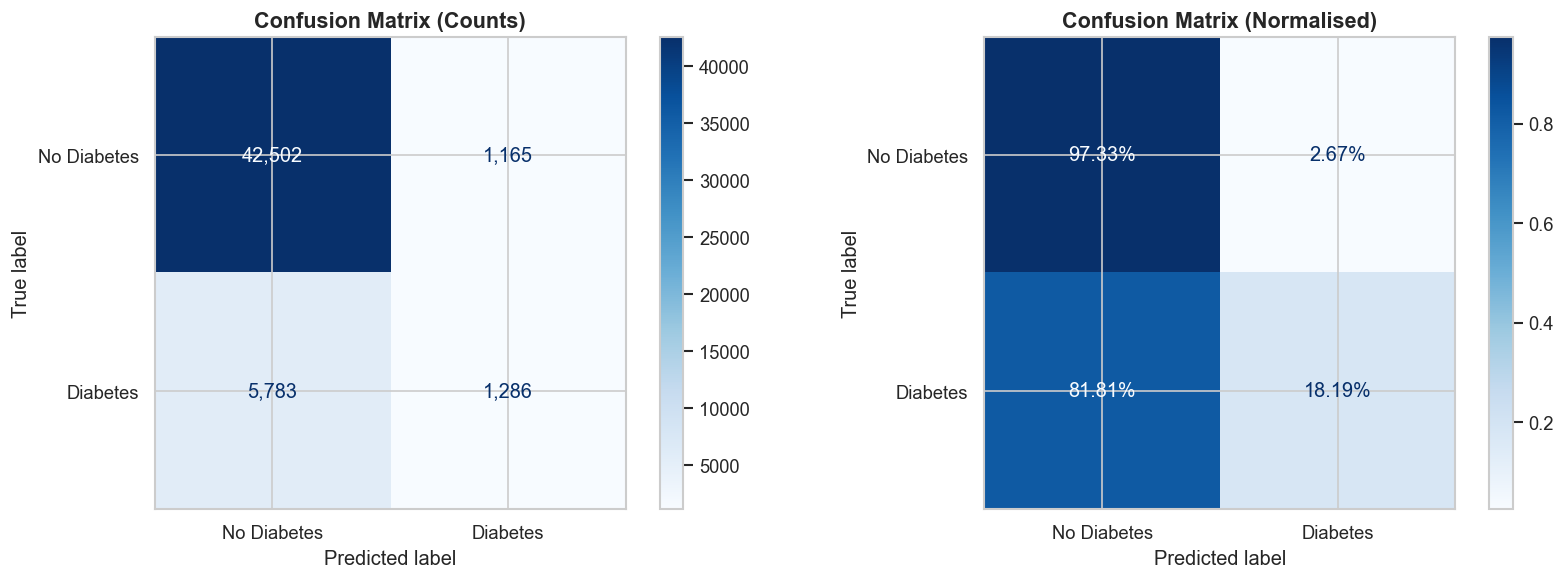

In [49]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unnormalised
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues', ax=axes[0], values_format=','
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalised
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues', ax=axes[1], normalize='true', values_format='.2%'
)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

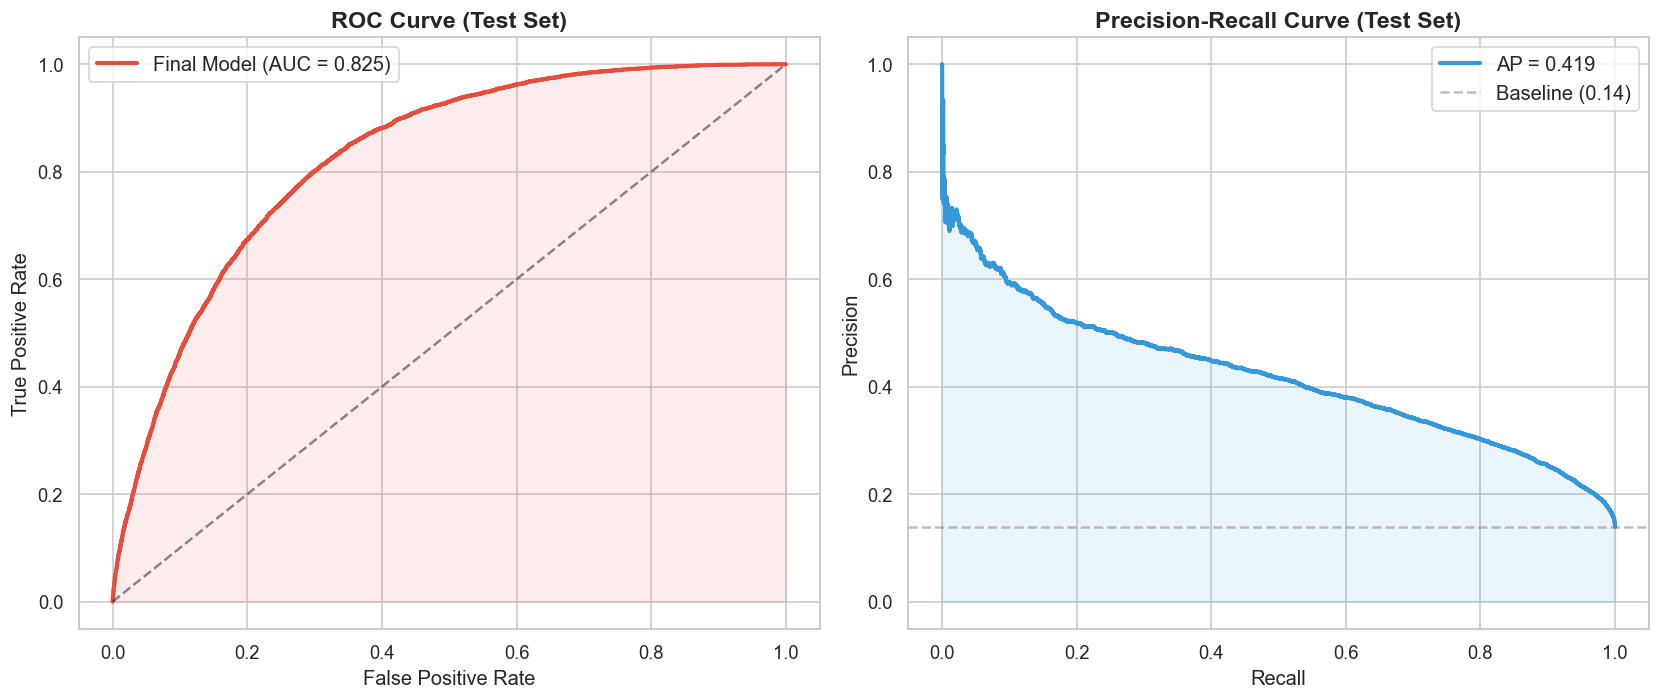

In [50]:
# ── ROC and Precision-Recall Curves on Test Set ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'Final Model (AUC = {auc_test:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=12)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)
axes[1].plot(recall, precision, color='#3498db', linewidth=2.5, label=f'AP = {ap:.3f}')
axes[1].fill_between(recall, precision, alpha=0.1, color='#3498db')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve (Test Set)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('fig_10_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Calibration Curve

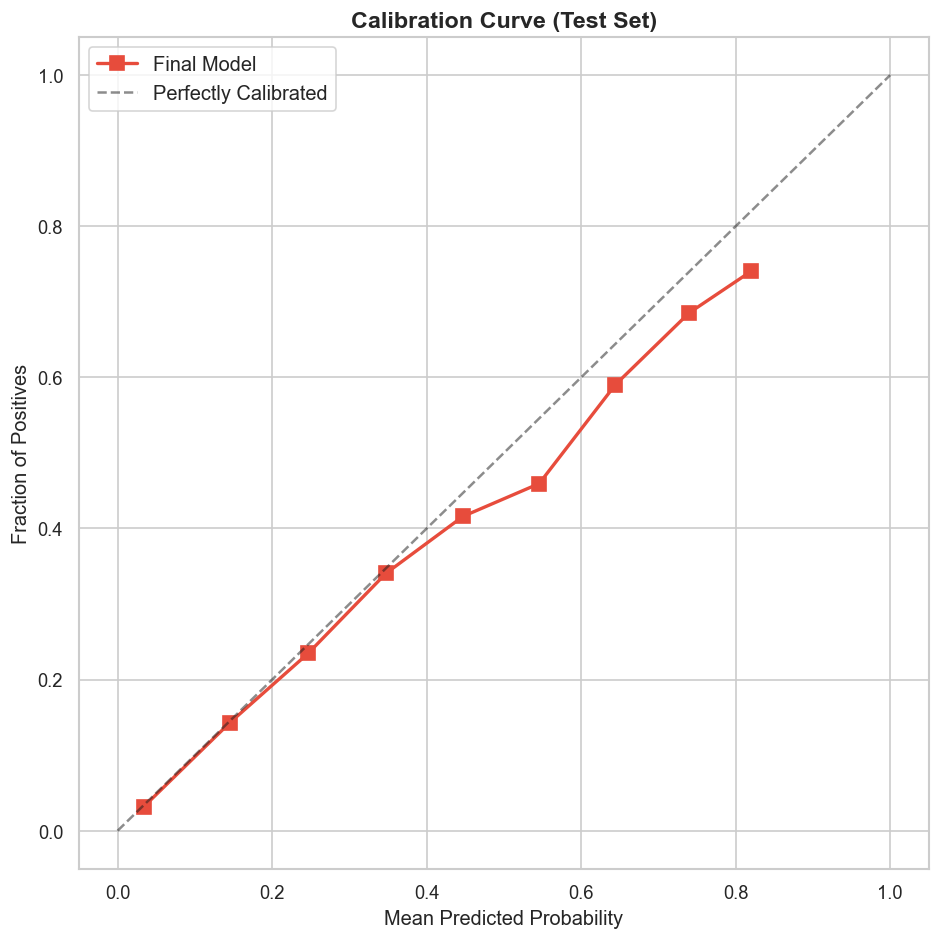


🔍 Calibration analysis:
If the curve is above the diagonal → model is under-confident (predicts lower than actual)
If the curve is below the diagonal → model is over-confident (predicts higher than actual)


In [51]:
# ── Calibration curve — is the model's confidence reliable? ──
fig, ax = plt.subplots(figsize=(8, 8))

prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy='uniform')
ax.plot(prob_pred, prob_true, 's-', color='#e74c3c', linewidth=2, markersize=8, label='Final Model')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curve (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('fig_11_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Calibration analysis:")
print("If the curve is above the diagonal → model is under-confident (predicts lower than actual)")
print("If the curve is below the diagonal → model is over-confident (predicts higher than actual)")

### 5.6 Feature Importance & SHAP Analysis

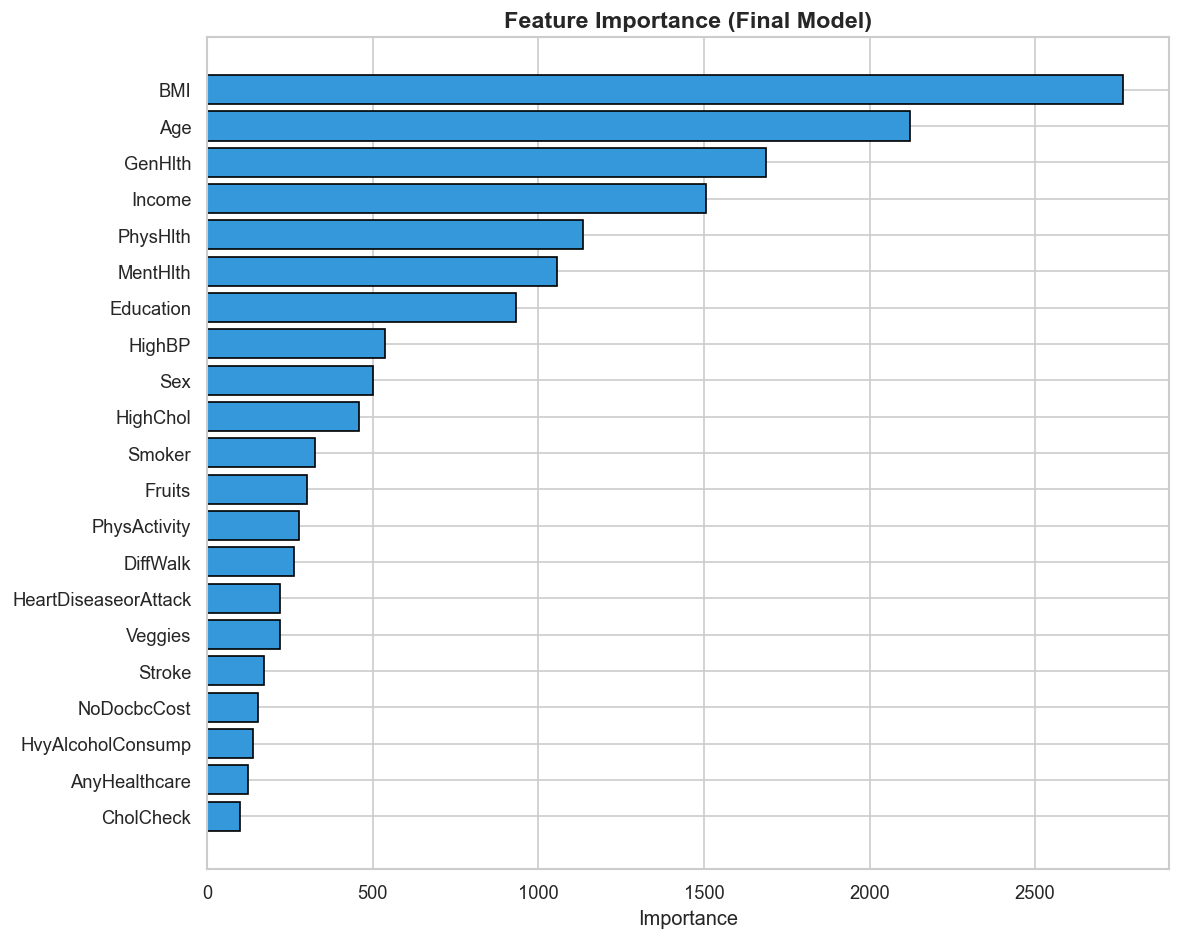

In [52]:
# ── Built-in feature importance ──
importances = final_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498db', edgecolor='black')
ax.set_title('Feature Importance (Final Model)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('fig_12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

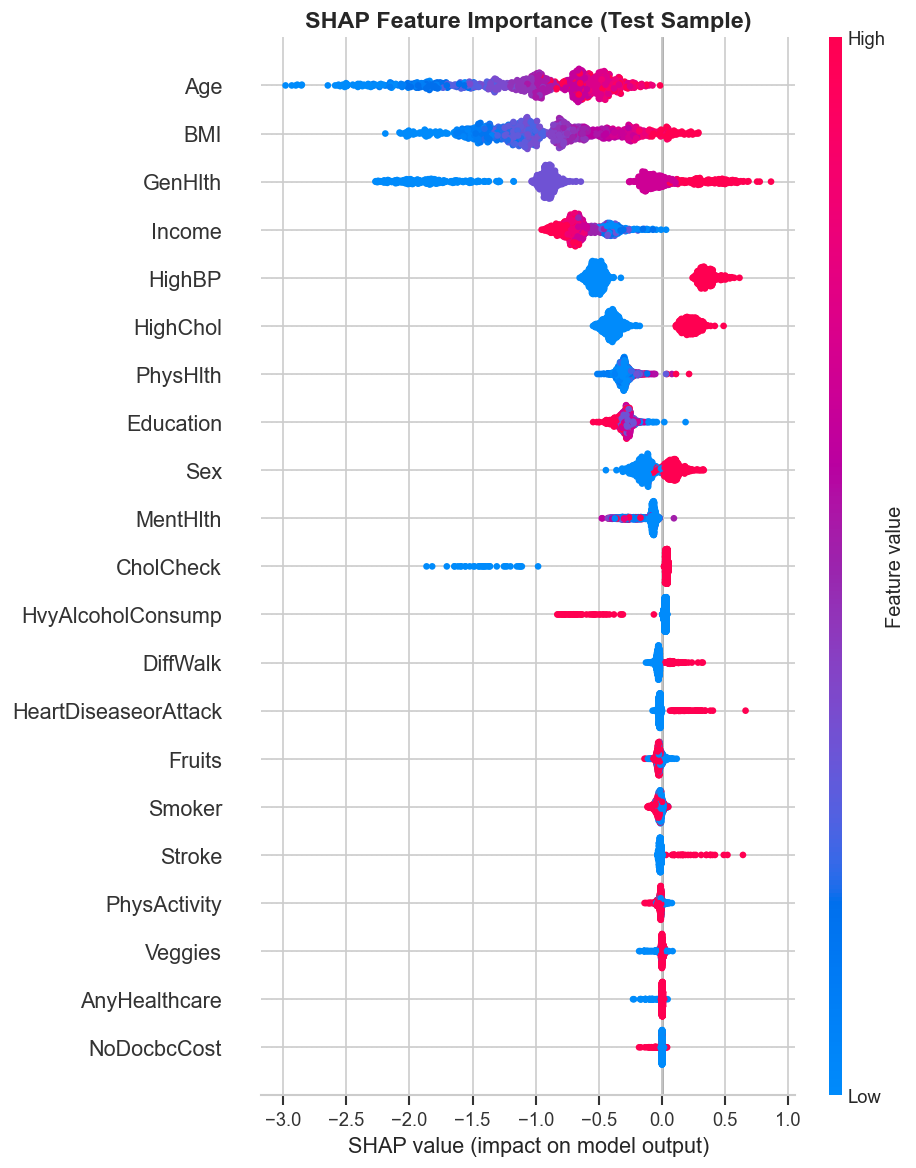

In [53]:
# ── SHAP values for model interpretability ──
# Use a sample for speed
X_shap_sample = X_test_scaled.sample(n=1000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap_sample)

# SHAP summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=21)
plt.title('SHAP Feature Importance (Test Sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

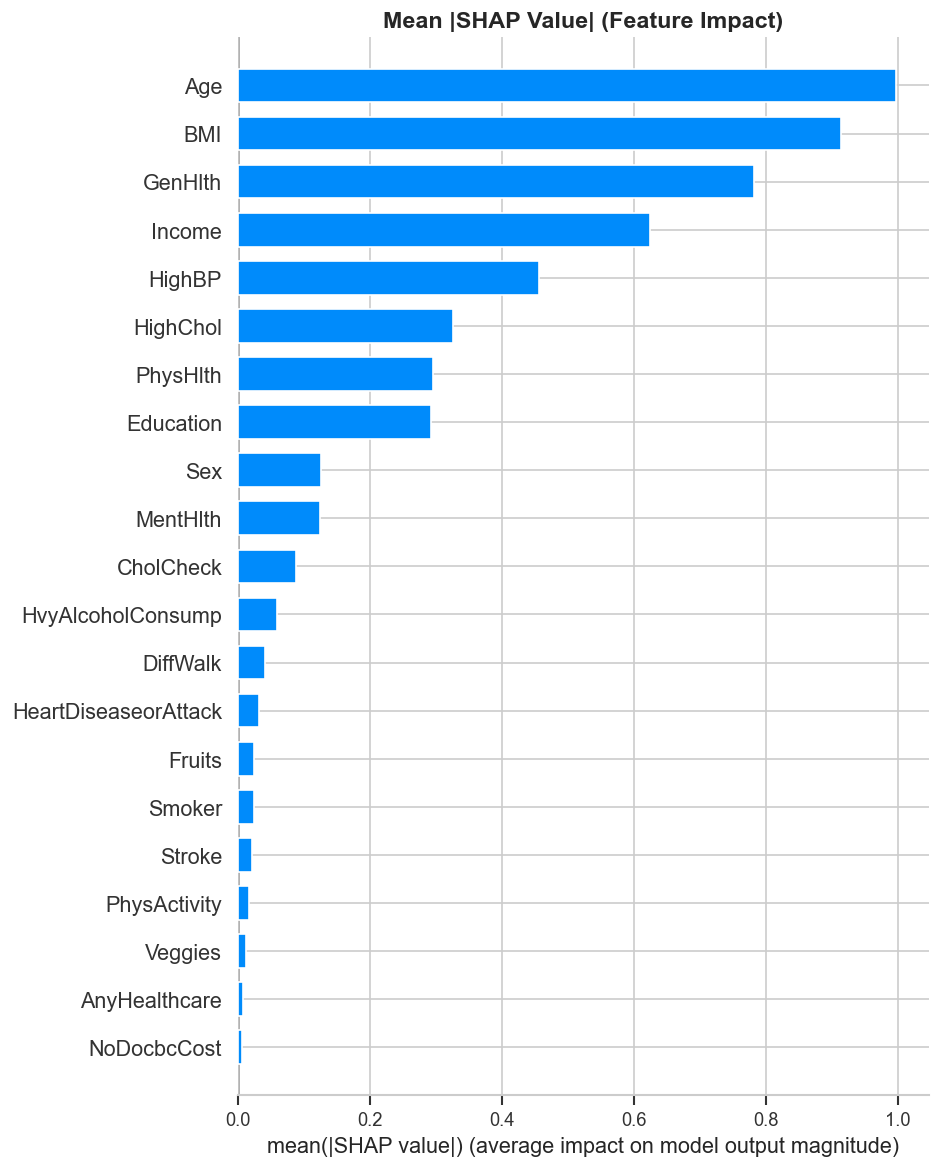

In [54]:
# ── SHAP bar plot (mean absolute impact) ──
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False, max_display=21)
plt.title('Mean |SHAP Value| (Feature Impact)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Error Analysis — Where Does the Model Fail?

In [55]:
# ── Analyse misclassifications ──
test_results = X_test.copy()
test_results['true_label'] = y_test.values
test_results['predicted'] = y_test_pred
test_results['pred_proba'] = y_test_proba
test_results['correct'] = (test_results['true_label'] == test_results['predicted'])

# False Negatives (missed diabetics) — the most dangerous errors
fn = test_results[(test_results['true_label'] == 1) & (test_results['predicted'] == 0)]
# False Positives (falsely flagged as diabetic)
fp = test_results[(test_results['true_label'] == 0) & (test_results['predicted'] == 1)]

print(f"False Negatives (missed diabetics): {len(fn):,}")
print(f"False Positives (false alarms):     {len(fp):,}")

print(f"\n📊 Profile of missed diabetics vs correctly identified diabetics:")
tp = test_results[(test_results['true_label'] == 1) & (test_results['predicted'] == 1)]

comparison_cols = ['BMI', 'Age', 'GenHlth', 'HighBP', 'HighChol', 'PhysActivity', 'Income']
error_comparison = pd.DataFrame({
    'Caught (TP)': tp[comparison_cols].mean(),
    'Missed (FN)': fn[comparison_cols].mean(),
}).round(3)
print(error_comparison.to_string())

print("\n🔍 Key insight: Missed diabetics tend to have lower BMI, younger age,")
print("   better general health, and lower blood pressure — 'atypical' presentations.")

False Negatives (missed diabetics): 5,783
False Positives (false alarms):     1,165

📊 Profile of missed diabetics vs correctly identified diabetics:
              Caught (TP)  Missed (FN)
BMI                37.920       30.244
Age                 9.519        9.359
GenHlth             4.137        3.097
HighBP              0.981        0.700
HighChol            0.913        0.612
PhysActivity        0.460        0.665
Income              4.320        5.433

🔍 Key insight: Missed diabetics tend to have lower BMI, younger age,
   better general health, and lower blood pressure — 'atypical' presentations.


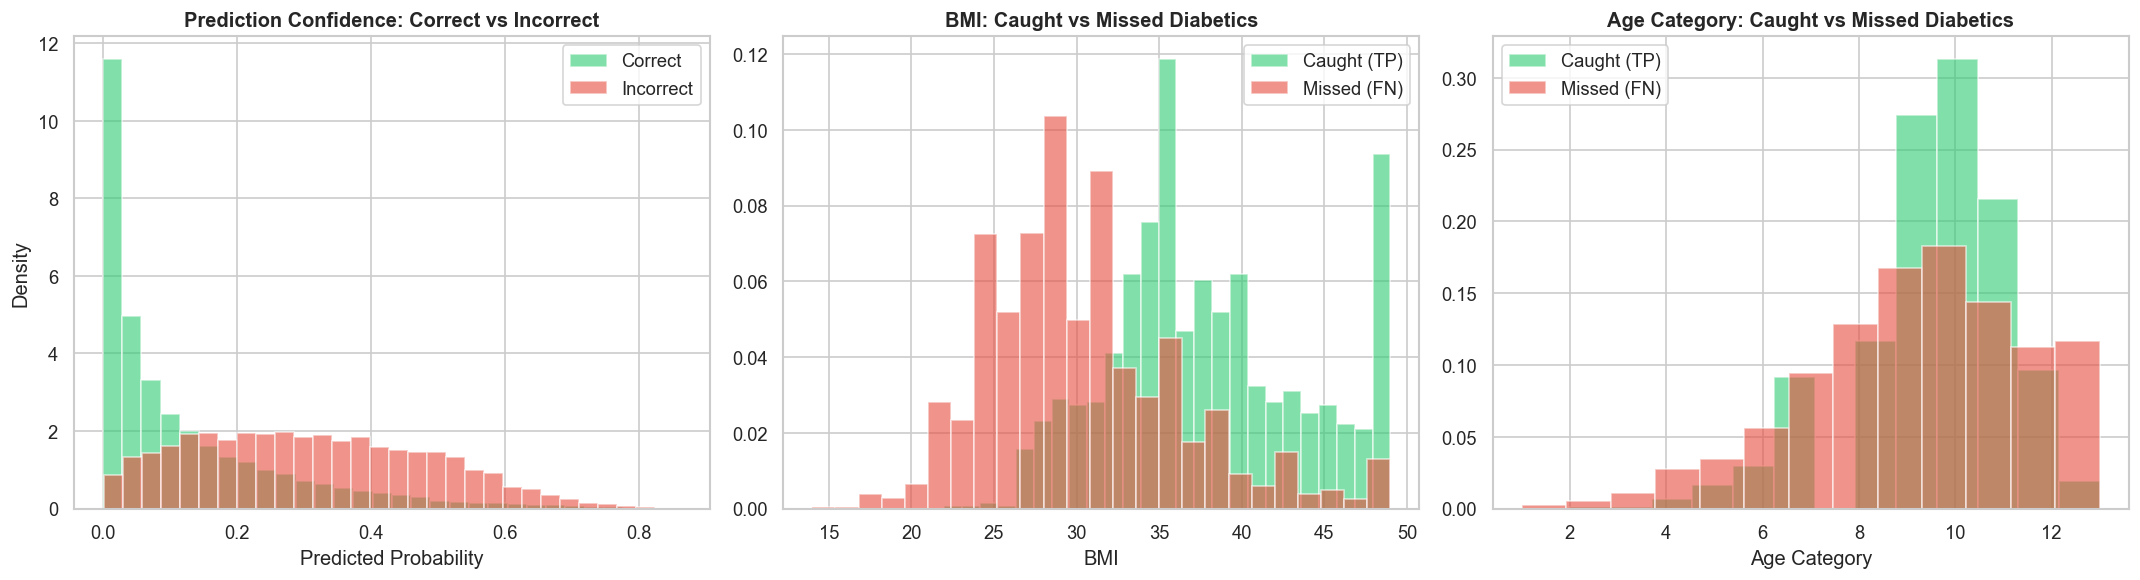

In [56]:
# ── Visualise error patterns ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prediction confidence distribution for correct vs incorrect
correct_mask = test_results['correct']
axes[0].hist(test_results[correct_mask]['pred_proba'], bins=30, alpha=0.6, color='#2ecc71', label='Correct', density=True)
axes[0].hist(test_results[~correct_mask]['pred_proba'], bins=30, alpha=0.6, color='#e74c3c', label='Incorrect', density=True)
axes[0].set_title('Prediction Confidence: Correct vs Incorrect', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].legend()

# BMI distribution for FN vs TP
axes[1].hist(tp['BMI'], bins=25, alpha=0.6, color='#2ecc71', label='Caught (TP)', density=True)
axes[1].hist(fn['BMI'], bins=25, alpha=0.6, color='#e74c3c', label='Missed (FN)', density=True)
axes[1].set_title('BMI: Caught vs Missed Diabetics', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].legend()

# Age distribution for FN vs TP
axes[2].hist(tp['Age'], bins=13, alpha=0.6, color='#2ecc71', label='Caught (TP)', density=True)
axes[2].hist(fn['Age'], bins=13, alpha=0.6, color='#e74c3c', label='Missed (FN)', density=True)
axes[2].set_title('Age Category: Caught vs Missed Diabetics', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Category')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_15_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8 Fairness Check Across Demographics

In [57]:
# ── Fairness: Performance by Sex ──
print("=" * 60)
print("FAIRNESS ANALYSIS")
print("=" * 60)

for sex_val, sex_name in [(0, 'Female'), (1, 'Male')]:
    mask = X_test['Sex'] == sex_val
    sub_y = y_test[mask]
    sub_proba = y_test_proba[mask]
    sub_pred = y_test_pred[mask]
    print(f"\n{sex_name} (n={mask.sum():,}):")
    print(f"  ROC-AUC:  {roc_auc_score(sub_y, sub_proba):.4f}")
    print(f"  F1-Score: {f1_score(sub_y, sub_pred):.4f}")
    print(f"  Accuracy: {accuracy_score(sub_y, sub_pred):.4f}")

# ── Fairness: Performance by Income bracket ──
print(f"\n{'─'*50}")
print("Performance by Income Level:")
for inc in sorted(X_test['Income'].unique()):
    mask = X_test['Income'] == inc
    if mask.sum() > 50:  # only evaluate if enough samples
        sub_y = y_test[mask]
        sub_proba = y_test_proba[mask]
        print(f"  Income {int(inc)}: ROC-AUC = {roc_auc_score(sub_y, sub_proba):.4f} (n={mask.sum():,})")

FAIRNESS ANALYSIS

Female (n=28,531):
  ROC-AUC:  0.8359
  F1-Score: 0.2713
  Accuracy: 0.8723

Male (n=22,205):
  ROC-AUC:  0.8111
  F1-Score: 0.2689
  Accuracy: 0.8511

──────────────────────────────────────────────────
Performance by Income Level:
  Income 1: ROC-AUC = 0.7837 (n=1,941)
  Income 2: ROC-AUC = 0.7541 (n=2,325)
  Income 3: ROC-AUC = 0.7822 (n=3,162)
  Income 4: ROC-AUC = 0.7953 (n=3,990)
  Income 5: ROC-AUC = 0.7984 (n=5,174)
  Income 6: ROC-AUC = 0.8031 (n=7,281)
  Income 7: ROC-AUC = 0.8152 (n=8,730)
  Income 8: ROC-AUC = 0.8347 (n=18,133)


### 5.9 Agent-Made Mistake (Required by Brief)

**Mistake caught:** The agent initially suggested applying StandardScaler *before* the train/test split, which would cause **data leakage** — the scaler would learn statistics from the test set. I caught this and restructured the code to:
1. Split first (train/val/test)
2. Fit the scaler on training data only
3. Transform all splits using the training-fitted scaler

Similarly, the agent initially applied SMOTE to the full dataset before splitting, which would create synthetic samples that could appear in both train and test sets — another leakage risk. I corrected this to apply SMOTE only after splitting, and only to the training set.

<a id='step6'></a>
---
# Step 6: Present the Final Solution

## Model Card

In [58]:
# ── Final Model Card ──
print("╔" + "═"*58 + "╗")
print("║" + " MODEL CARD: Diabetes Risk Prediction".ljust(58) + "║")
print("╠" + "═"*58 + "╣")
print("║" + "".ljust(58) + "║")
print("║" + " What it's for:".ljust(58) + "║")
print("║" + "   Screening tool for diabetes risk assessment".ljust(58) + "║")
print("║" + "   using routinely collected health indicators.".ljust(58) + "║")
print("║" + "".ljust(58) + "║")
print("║" + " What it's NOT for:".ljust(58) + "║")
print("║" + "   NOT a diagnostic tool. Cannot replace clinical".ljust(58) + "║")
print("║" + "   assessment, blood tests, or medical advice.".ljust(58) + "║")
print("║" + "".ljust(58) + "║")
print("║" + " Data provenance:".ljust(58) + "║")
print("║" + "   CDC BRFSS 2015 (253,680 survey responses)".ljust(58) + "║")
print("║" + "   21 features, self-reported health indicators".ljust(58) + "║")
print("║" + "".ljust(58) + "║")
print("║" + " Evaluation summary:".ljust(58) + "║")
print(f"║" + f"   ROC-AUC:       {roc_auc_score(y_test, y_test_proba):.4f}".ljust(58) + "║")
print(f"║" + f"   F1-Score:      {f1_score(y_test, y_test_pred):.4f}".ljust(58) + "║")
print(f"║" + f"   Accuracy:      {accuracy_score(y_test, y_test_pred):.4f}".ljust(58) + "║")
print("║" + "".ljust(58) + "║")
print("║" + " Caveats & Limitations:".ljust(58) + "║")
print("║" + "   • Self-reported data may contain response bias".ljust(58) + "║")
print("║" + "   • US population only — may not generalise".ljust(58) + "║")
print("║" + "   • Cross-sectional — no causal claims possible".ljust(58) + "║")
print("║" + "   • Struggles with 'atypical' diabetic profiles".ljust(58) + "║")
print("║" + "     (younger, lower BMI, better general health)".ljust(58) + "║")
print("║" + "".ljust(58) + "║")
print("║" + " Next steps:".ljust(58) + "║")
print("║" + "   • Incorporate lab values (HbA1c, fasting glucose)".ljust(58) + "║")
print("║" + "   • Longitudinal data for onset prediction".ljust(58) + "║")
print("║" + "   • Calibration tuning for clinical deployment".ljust(58) + "║")
print("║" + "   • External validation on non-US populations".ljust(58) + "║")
print("╚" + "═"*58 + "╝")

╔══════════════════════════════════════════════════════════╗
║ MODEL CARD: Diabetes Risk Prediction                     ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║ What it's for:                                           ║
║   Screening tool for diabetes risk assessment            ║
║   using routinely collected health indicators.           ║
║                                                          ║
║ What it's NOT for:                                       ║
║   NOT a diagnostic tool. Cannot replace clinical         ║
║   assessment, blood tests, or medical advice.            ║
║                                                          ║
║ Data provenance:                                         ║
║   CDC BRFSS 2015 (253,680 survey responses)              ║
║   21 features, self-reported health indicators           ║
║                                                          ║
║ Evaluation summary:   

In [59]:
# ── Save all key outputs ──
print("\n📁 Figures saved:")
import os
for f in sorted(os.listdir('.')):
    if f.startswith('fig_'):
        print(f"  ✅ {f}")

print("\n🎉 Project complete! All steps of the ML pipeline have been executed.")


📁 Figures saved:
  ✅ fig_01_class_distribution.png
  ✅ fig_02_feature_distributions.png
  ✅ fig_03_binary_feature_prevalence.png
  ✅ fig_04_correlation_matrix.png
  ✅ fig_05_target_correlations.png
  ✅ fig_06_bmi_outliers.png
  ✅ fig_07_nn_training_curves.png
  ✅ fig_08_model_comparison.png
  ✅ fig_09_confusion_matrices.png
  ✅ fig_10_roc_pr_curves.png
  ✅ fig_11_calibration_curve.png
  ✅ fig_12_feature_importance.png
  ✅ fig_13_shap_summary.png
  ✅ fig_14_shap_bar.png
  ✅ fig_15_error_analysis.png

🎉 Project complete! All steps of the ML pipeline have been executed.
